# The resource-consumer NP model with odeint

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#submission folder
main_folder = Path("Baliti_Ocean Modelling Exercises")
figures_folder = main_folder / "Figures"
figures_folder.mkdir(parents=True, exist_ok=True)

The code below represents the dynamics
$$\frac{dN}{dt}=-k NP$$
$$\frac{dP}{dt}=k NP$$
The parameter $k$ is an input to the function

In [3]:
# function that returns the right hand side of the above equations
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

Set the initial conditions, the time axis and solve the ODE

In [4]:
# initial conditions
K = 0.1
N0 = 5.
P0 = 0.1
state0 = np.array([N0,P0])

# time points (days)
t = np.linspace(0,20,num=100)

# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,))

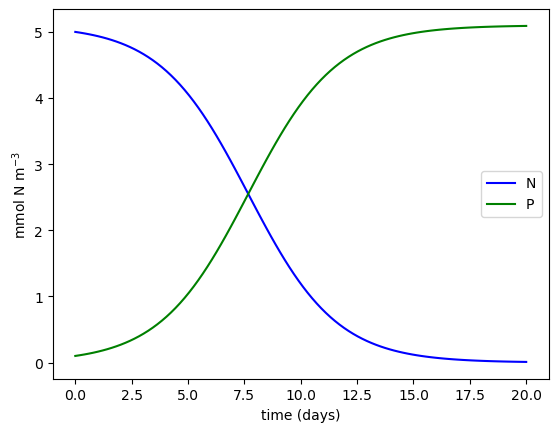

In [5]:
# plot the resulting time series
plt.plot(t,y[:,0],'b',label='N')
plt.plot(t,y[:,1],'g',label='P')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()
plt.show()

# Exercise

1. 
The inputs in the function model are state, t and k.

The output of the function is an array containing Ndot and Pdot.


2. Write a new model to simulate the nutrient-phytoplankton-detritus system (NPD). Include a detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. This will involve adding 2 new parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.

The model equations can be written using latex. Check the code in the inital cell above. Otherwise you can use the equation editor on Word or LibreOffice.

The equations are:

$$
\frac{dN}{dt} = -kNP + rD
$$

$$
\frac{dP}{dt} = kNP - mP
$$

$$
\frac{dD}{dt} = mP - rD
$$

3. Write the code to solve the new model using odeint and propose some reasonable values for the parameters that lead to a realistic solution

In [6]:
#NPD model function
def NPD_model(state, t, k, m, r):
    N, P, D = state

    Ndot = -k * N * P + r * D
    Pdot =  k * N * P - m * P
    Ddot =  m * P - r * D

    return np.array([Ndot, Pdot, Ddot])

In [7]:
#Parameters
k = 0.1      # nutrient uptake rate
m = 0.05     # phytoplankton mortality rate
r = 0.02     # remineralisation rate

#Initial conditions
N0 = 5.0
P0 = 0.1
D0 = 0.0

state0_npd = np.array([N0, P0, D0])
t_npd = np.linspace(0, 100, num=500)

#NPD model
y_npd = odeint(NPD_model, state0_npd, t_npd, args=(k, m, r))

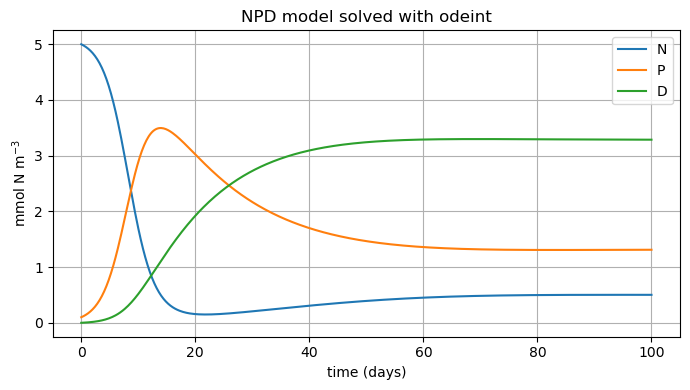

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(t_npd, y_npd[:, 0], label='N')
plt.plot(t_npd, y_npd[:, 1], label='P')
plt.plot(t_npd, y_npd[:, 2], label='D')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.title('NPD model solved with odeint')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figures_folder / 'ex7_npd_model.png', dpi=200)
plt.show()